# Project A — CRM Donor Analysis

# Nonprofit CRM Data Analysis Case Study

## Project Overview

This project analyzes a nonprofit donor CRM dataset (5,000 donors) to identify behavioral patterns, revenue concentration, and retention risks using RFM-based segmentation and exploratory data analysis.

## Business Objective

To provide data-driven insights that support:

- Major gift identification
- Revenue concentration analysis
- Retention strategy development
- Donor portfolio segmentation
- Campaign targeting optimization

## Analytical Approach

1. Data cleaning & validation  
2. Feature engineering (Recency, High-Value flags)  
3. Exploratory data analysis  
4. Pareto revenue concentration modeling  
5. RFM tier segmentation  
6. Strategic insight framing  

---

## Key Strategic Findings

- The top 20% of donors contribute ~36% of revenue (moderate concentration).
- Recency distribution suggests meaningful lapse risk across the donor base.
- Frequency strongly correlates with lifetime giving.
- RFM segmentation reveals actionable tiers for portfolio assignment.

---

## Recommended Strategic Actions

- Deploy major gift cultivation to high-RFM donors.
- Launch recurring gift upgrades for mid-tier donors.
- Implement reactivation campaigns for high-recency-risk segments.
- Use segmentation for data-informed campaign targeting.

## 1. Project Overview

This project simulates cleaning and preparing a nonprofit CRM dataset for donor behavior and segmentation analysis.

Business Context

This dataset represents a simulated university fundraising CRM system.

The objective is to clean, structure, and prepare the data for:

Donor segmentation

Recency–Frequency–Monetary modeling

Behavioral insights

Fundraising strategy support

## 2. Data Intake

In [2]:
import pandas as pd

df = pd.read_csv("../data/crm_raw.csv")

df.head()

,DonorID,FirstName,LastName,Email,Phone,City,State,ZipCode,LastDonationDate,TotalGifts,TotalAmountDonated,EventParticipation,EngagementScore
0,D00001,Danielle,Anderson,tina69@salazar.com,(716)033-8417x8760,New Ethan,AK,9539,9/3/2024,10,8481.55,Yes,56
1,D00002,Angel,Hart,garciatyler@gmail.com,(874)907-2648,West Ashleymouth,MS,49618,5/6/2022,5,14102.15,Yes,11
2,D00003,Joshua,Stone,ywoods@gmail.com,105.039.1678x12883,East Stephanie,NJ,6600,1/21/2023,21,5140.38,No,26
3,D00004,Jeffrey,Welch,johnsonkimberly@ferguson.com,939.859.3082x278,South Andrewshire,SD,22434,1/26/2023,22,18555.04,Yes,92
4,D00005,Jill,Vasquez,hughesnicholas@gmail.com,469-539-5369,Moorestad,DC,16142,5/5/2022,10,1325.93,No,27


In [3]:
import sys
sys.executable

'/Library/Developer/CommandLineTools/usr/bin/python3'

In [4]:
import pandas as pd

df = pd.read_csv("../data/crm_raw.csv")

df.head()

,DonorID,FirstName,LastName,Email,Phone,City,State,ZipCode,LastDonationDate,TotalGifts,TotalAmountDonated,EventParticipation,EngagementScore
0,D00001,Danielle,Anderson,tina69@salazar.com,(716)033-8417x8760,New Ethan,AK,9539,9/3/2024,10,8481.55,Yes,56
1,D00002,Angel,Hart,garciatyler@gmail.com,(874)907-2648,West Ashleymouth,MS,49618,5/6/2022,5,14102.15,Yes,11
2,D00003,Joshua,Stone,ywoods@gmail.com,105.039.1678x12883,East Stephanie,NJ,6600,1/21/2023,21,5140.38,No,26
3,D00004,Jeffrey,Welch,johnsonkimberly@ferguson.com,939.859.3082x278,South Andrewshire,SD,22434,1/26/2023,22,18555.04,Yes,92
4,D00005,Jill,Vasquez,hughesnicholas@gmail.com,469-539-5369,Moorestad,DC,16142,5/5/2022,10,1325.93,No,27


In [5]:
import sys
!{sys.executable} -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [6]:
import pandas as pd
pd.__version__

'2.3.3'

## 3. Data Quality Checks

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DonorID             5000 non-null   object 
 1   FirstName           5000 non-null   object 
 2   LastName            5000 non-null   object 
 3   Email               5000 non-null   object 
 4   Phone               5000 non-null   object 
 5   City                5000 non-null   object 
 6   State               5000 non-null   object 
 7   ZipCode             5000 non-null   int64  
 8   LastDonationDate    5000 non-null   object 
 9   TotalGifts          5000 non-null   int64  
 10  TotalAmountDonated  5000 non-null   float64
 11  EventParticipation  5000 non-null   object 
 12  EngagementScore     5000 non-null   int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 507.9+ KB


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DonorID             5000 non-null   object 
 1   FirstName           5000 non-null   object 
 2   LastName            5000 non-null   object 
 3   Email               5000 non-null   object 
 4   Phone               5000 non-null   object 
 5   City                5000 non-null   object 
 6   State               5000 non-null   object 
 7   ZipCode             5000 non-null   int64  
 8   LastDonationDate    5000 non-null   object 
 9   TotalGifts          5000 non-null   int64  
 10  TotalAmountDonated  5000 non-null   float64
 11  EventParticipation  5000 non-null   object 
 12  EngagementScore     5000 non-null   int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 507.9+ KB


In [9]:
df.describe()

,ZipCode,TotalGifts,TotalAmountDonated,EngagementScore
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,50231.523400,15.261400,12350.097270,50.899600
std,28624.962295,8.292504,7133.844628,28.996284
min,523.000000,1.000000,21.320000,1.000000
25%,25877.500000,8.000000,6248.907500,26.000000
50%,49843.000000,15.000000,12304.270000,51.000000
75%,74898.000000,22.000000,18440.480000,76.000000
max,99936.000000,29.000000,24991.840000,100.000000


In [10]:
df.describe(include='object')

,DonorID,FirstName,LastName,Email,Phone,City,State,LastDonationDate,EventParticipation
count,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,601,931,4987,4997,4234,51,1086,2
top,D00001,Michael,Smith,karen00@yahoo.com,-8490,South Michael,FL,9/5/2022,No
freq,1,104,100,2,2,7,119,12,3211


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]

,DonorID,FirstName,LastName,Email,Phone,City,State,ZipCode,LastDonationDate,TotalGifts,TotalAmountDonated,EventParticipation,EngagementScore


In [13]:
df['LastDonationDate'] = pd.to_datetime(df['LastDonationDate'])

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/crm_raw.csv")

In [12]:
df = pd.read_csv("../data/crm_raw.csv")

In [13]:
df.shape

(5000, 13)

In [14]:
df.head()

,DonorID,FirstName,LastName,Email,Phone,City,State,ZipCode,LastDonationDate,TotalGifts,TotalAmountDonated,EventParticipation,EngagementScore
0,D00001,Danielle,Anderson,tina69@salazar.com,(716)033-8417x8760,New Ethan,AK,9539,9/3/2024,10,8481.55,Yes,56
1,D00002,Angel,Hart,garciatyler@gmail.com,(874)907-2648,West Ashleymouth,MS,49618,5/6/2022,5,14102.15,Yes,11
2,D00003,Joshua,Stone,ywoods@gmail.com,105.039.1678x12883,East Stephanie,NJ,6600,1/21/2023,21,5140.38,No,26
3,D00004,Jeffrey,Welch,johnsonkimberly@ferguson.com,939.859.3082x278,South Andrewshire,SD,22434,1/26/2023,22,18555.04,Yes,92
4,D00005,Jill,Vasquez,hughesnicholas@gmail.com,469-539-5369,Moorestad,DC,16142,5/5/2022,10,1325.93,No,27


In [16]:
df["LastDonationDate"] = pd.to_datetime(df["LastDonationDate"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DonorID             5000 non-null   object        
 1   FirstName           5000 non-null   object        
 2   LastName            5000 non-null   object        
 3   Email               5000 non-null   object        
 4   Phone               5000 non-null   object        
 5   City                5000 non-null   object        
 6   State               5000 non-null   object        
 7   ZipCode             5000 non-null   int64         
 8   LastDonationDate    5000 non-null   datetime64[ns]
 9   TotalGifts          5000 non-null   int64         
 10  TotalAmountDonated  5000 non-null   float64       
 11  EventParticipation  5000 non-null   object        
 12  EngagementScore     5000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3), obje

In [18]:
df["ZipCode"] = df["ZipCode"].astype(str)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   DonorID             5000 non-null   object        
 1   FirstName           5000 non-null   object        
 2   LastName            5000 non-null   object        
 3   Email               5000 non-null   object        
 4   Phone               5000 non-null   object        
 5   City                5000 non-null   object        
 6   State               5000 non-null   object        
 7   ZipCode             5000 non-null   object        
 8   LastDonationDate    5000 non-null   datetime64[ns]
 9   TotalGifts          5000 non-null   int64         
 10  TotalAmountDonated  5000 non-null   float64       
 11  EventParticipation  5000 non-null   object        
 12  EngagementScore     5000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), obje

In [20]:
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

In [21]:
df["State"] = df["State"].str.upper()
df["City"] = df["City"].str.title()
df["FirstName"] = df["FirstName"].str.title()
df["LastName"] = df["LastName"].str.title()
df["EventParticipation"] = df["EventParticipation"].str.title()

In [22]:
df.isnull().sum()

DonorID               0
FirstName             0
LastName              0
Email                 0
Phone                 0
City                  0
State                 0
ZipCode               0
LastDonationDate      0
TotalGifts            0
TotalAmountDonated    0
EventParticipation    0
EngagementScore       0
dtype: int64

## 4. Feature Engineering

In [23]:
from datetime import datetime

today = datetime.today()

df["RecencyDays"] = (today - df["LastDonationDate"]).dt.days

In [24]:
df["RecencyDays"].describe()

count    5000.000000
mean      901.166400
std       314.496755
min       347.000000
25%       634.000000
50%       901.000000
75%      1176.250000
max      1442.000000
Name: RecencyDays, dtype: float64

In [25]:
df["HighValueDonor"] = df["TotalAmountDonated"] > 15000

In [26]:
df["HighValueDonor"].value_counts()

HighValueDonor
False    3092
True     1908
Name: count, dtype: int64

In [27]:
df["EngagementTier"] = pd.cut(
    df["EngagementScore"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)

In [28]:
df["EngagementTier"].value_counts()

EngagementTier
High      1728
Medium    1665
Low       1607
Name: count, dtype: int64

In [29]:
df.groupby("EngagementTier")["TotalAmountDonated"].mean()

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9369/1203716270.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("EngagementTier")["TotalAmountDonated"].mean()


EngagementTier
Low       12310.090828
Medium    12438.846943
High      12301.788328
Name: TotalAmountDonated, dtype: float64

In [30]:
df.groupby("HighValueDonor")["RecencyDays"].mean()

HighValueDonor
False    900.208603
True     902.718553
Name: RecencyDays, dtype: float64

In [31]:
df.groupby("EngagementTier")["RecencyDays"].mean()

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9369/673727760.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("EngagementTier")["RecencyDays"].mean()


EngagementTier
Low       911.537648
Medium    893.902102
High      898.520833
Name: RecencyDays, dtype: float64

In [32]:
df[["TotalGifts", "TotalAmountDonated", "EngagementScore", "RecencyDays"]].corr()

,TotalGifts,TotalAmountDonated,EngagementScore,RecencyDays
TotalGifts,1.000000,-0.001263,0.008760,0.007857
TotalAmountDonated,-0.001263,1.000000,-0.005283,0.000196
EngagementScore,0.008760,-0.005283,1.000000,-0.016855
RecencyDays,0.007857,0.000196,-0.016855,1.000000


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["TotalAmountDonated"], bins=30)
plt.title("Distribution of Total Amount Donated")
plt.xlabel("Total Amount Donated")
plt.ylabel("Count")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df["RecencyDays"], bins=30)
plt.title("Distribution of Recency (Days Since Last Donation)")
plt.xlabel("Recency (Days)")
plt.ylabel("Count")
plt.show()

NameError: name 'plt' is not defined

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="EngagementTier", data=df, order=["Low","Medium","High"])
plt.title("Donor Distribution by Engagement Tier")
plt.show()

NameError: name 'plt' is not defined

In [36]:
!pip install matplotlib seaborn

zsh:1: command not found: pip


In [1]:
!pip install matplotlib seaborn

zsh:1: command not found: pip


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
!python -m pip install matplotlib seaborn

zsh:1: command not found: python


In [4]:
!pip3 install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 68.5 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 42.2 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 47.4 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 65.7 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 79.7 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
print(sys.executable)
!pip3 show matplotlib

/Library/Developer/CommandLineTools/usr/bin/python3
Name: matplotlib
Version: 3.9.4
Summary: Python plotting package
Home-page: 
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later
         
         1. This LICENSE AGREEMENT is between the Matplotlib Development Team
         ("MDT"), and the Individual or Organization ("Licensee") accessing and
         otherwise using matplotlib software in source or binary form and its
         associated documentation.
         
         2. Subject to the terms and conditions of this License Agreement, MDT
         hereby grants Licensee a nonexclusive, royalty-free, world-wide license
         to reproduce, analyze, test, perform and/or display publicly, prepare
         derivative works, distribute, and otherwise use matplotlib
         alone or in any derivative version, provided, however, that MDT's
         License Agreement and MDT's

In [3]:
import sys
print("Kernel python:", sys.executable)

# install into the *same* python your kernel is using
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install matplotlib seaborn

Kernel python: /Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.8 MB 10.5 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable


In [1]:
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)

matplotlib: 3.9.4
seaborn: 0.13.2


In [2]:
plt.figure(figsize=(8,5))
plt.hist(df["TotalAmountDonated"], bins=30)
plt.title("Distribution of Total Amount Donated")
plt.xlabel("TotalAmountDonated")
plt.ylabel("Count")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [3]:
import pandas as pd

df = pd.read_csv("../data/crm_raw.csv")
df.shape

(5000, 13)

## 5. Exploratory Data Analysis

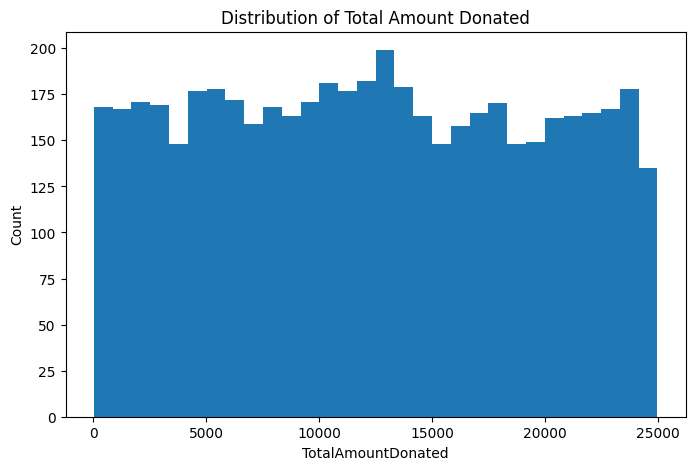

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["TotalAmountDonated"], bins=30)
plt.title("Distribution of Total Amount Donated")
plt.xlabel("TotalAmountDonated")
plt.ylabel("Count")
plt.show()

### Insight: Distribution of Total Giving

**What we see:**  
Total lifetime donation amounts are widely distributed across donors, with no extreme right-skew concentration. Donation values appear relatively evenly spread across the range.

**Why it matters:**  
This suggests the donor base is diversified rather than dependent on a very small ultra-major gift segment. However, segmentation strategies may still identify high-value cohorts for targeted cultivation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["TotalAmountDonated"]), bins=30)
plt.title("Log Distribution of Total Amount Donated")
plt.xlabel("log(1 + TotalAmountDonated)")
plt.ylabel("Count")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [2]:
plt.figure(figsize=(8,2))
plt.boxplot(df["TotalAmountDonated"], vert=False)
plt.title("Total Amount Donated (Boxplot)")
plt.xlabel("TotalAmountDonated")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x200 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["TotalAmountDonated"]), bins=30)
plt.title("Log Distribution of Total Amount Donated")
plt.xlabel("log(1 + TotalAmountDonated)")
plt.ylabel("Count")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x500 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/crm_raw.csv")
df.shape

(5000, 13)

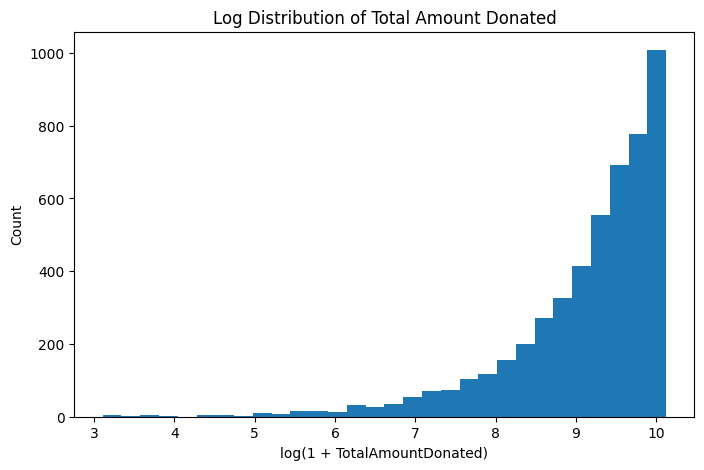

In [4]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["TotalAmountDonated"]), bins=30)
plt.title("Log Distribution of Total Amount Donated")
plt.xlabel("log(1 + TotalAmountDonated)")
plt.ylabel("Count")
plt.show()

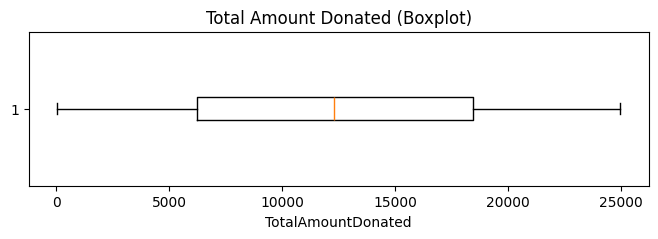

In [5]:
plt.figure(figsize=(8,2))
plt.boxplot(df["TotalAmountDonated"], vert=False)
plt.title("Total Amount Donated (Boxplot)")
plt.xlabel("TotalAmountDonated")
plt.show()

In [6]:
df.groupby("EngagementTier")["TotalAmountDonated"].describe()

KeyError: 'EngagementTier'

In [7]:
plt.figure(figsize=(8,5))
df.boxplot(column="TotalAmountDonated", by="EngagementTier")
plt.title("Donation Distribution by Engagement Tier")
plt.suptitle("")
plt.ylabel("TotalAmountDonated")
plt.show()

KeyError: 'EngagementTier'

<Figure size 800x500 with 0 Axes>

In [8]:
df.columns

Index(['DonorID', 'FirstName', 'LastName', 'Email', 'Phone', 'City', 'State',
       'ZipCode', 'LastDonationDate', 'TotalGifts', 'TotalAmountDonated',
       'EventParticipation', 'EngagementScore'],
      dtype='object')

In [10]:
import pandas as pd

# make sure EngagementScore is numeric
df["EngagementScore"] = pd.to_numeric(df["EngagementScore"], errors="coerce")

df["EngagementTier"] = pd.cut(
    df["EngagementScore"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [11]:
df["EngagementTier"].value_counts(dropna=False)

EngagementTier
High      1728
Medium    1665
Low       1607
Name: count, dtype: int64

In [12]:
df.groupby("EngagementTier")["TotalAmountDonated"].describe()

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/1942250675.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("EngagementTier")["TotalAmountDonated"].describe()


,count,mean,std,min,25%,50%,75%,max
EngagementTier,,,,,,,,
Low,1607.0,12310.090828,7126.791473,21.32,6207.49,12313.07,18306.6150,24991.84
Medium,1665.0,12438.846943,7203.370360,26.02,6247.40,12438.90,18588.9600,24987.64
High,1728.0,12301.788328,7076.181910,26.07,6307.96,12096.12,18364.5575,24980.20


<Figure size 800x500 with 0 Axes>

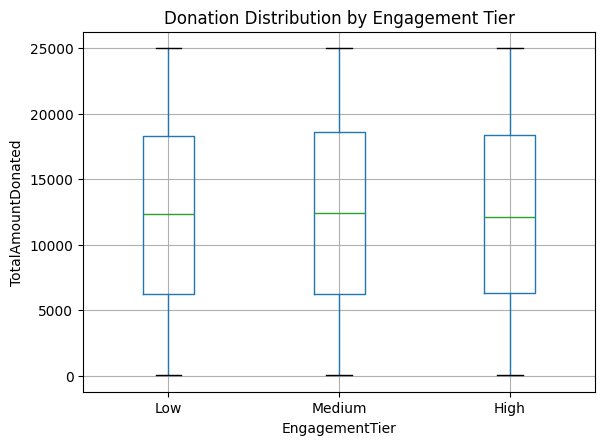

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="TotalAmountDonated", by="EngagementTier")
plt.title("Donation Distribution by Engagement Tier")
plt.suptitle("")
plt.ylabel("TotalAmountDonated")
plt.show()

In [14]:
df[["EngagementScore", "TotalAmountDonated"]].corr()

,EngagementScore,TotalAmountDonated
EngagementScore,1.000000,-0.005283
TotalAmountDonated,-0.005283,1.000000


In [15]:
df.groupby("EngagementTier")["DonationCount"].describe()

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/4047813810.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("EngagementTier")["DonationCount"].describe()


KeyError: 'Column not found: DonationCount'

KeyError: 'Column not found: DonationCount'

<Figure size 800x500 with 0 Axes>

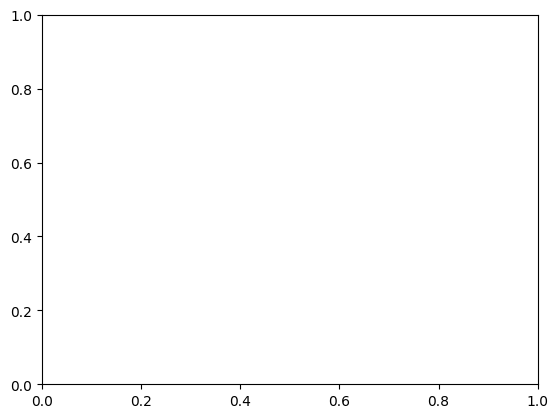

In [16]:
plt.figure(figsize=(8,5))
df.boxplot(column="DonationCount", by="EngagementTier")
plt.title("Donation Count by Engagement Tier")
plt.suptitle("")
plt.ylabel("DonationCount")
plt.show()

In [17]:
df.columns

Index(['DonorID', 'FirstName', 'LastName', 'Email', 'Phone', 'City', 'State',
       'ZipCode', 'LastDonationDate', 'TotalGifts', 'TotalAmountDonated',
       'EventParticipation', 'EngagementScore', 'EngagementTier'],
      dtype='object')

In [18]:
df.groupby("EngagementTier")["TotalGifts"].describe()

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/3730924131.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("EngagementTier")["TotalGifts"].describe()


,count,mean,std,min,25%,50%,75%,max
EngagementTier,,,,,,,,
Low,1607.0,15.268824,8.272141,1.0,8.0,15.0,22.5,29.0
Medium,1665.0,15.060060,8.343583,1.0,8.0,15.0,22.0,29.0
High,1728.0,15.448495,8.262325,1.0,8.0,16.0,23.0,29.0


<Figure size 800x500 with 0 Axes>

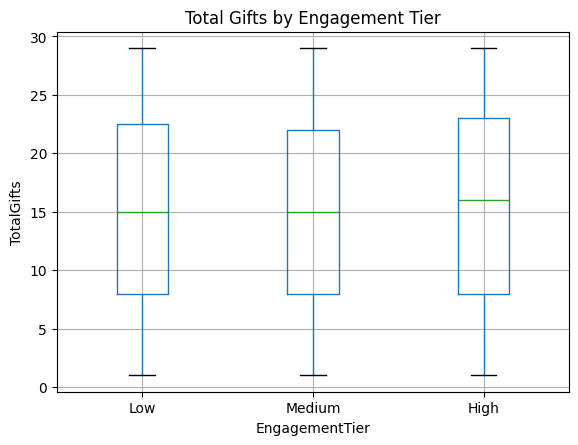

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="TotalGifts", by="EngagementTier")
plt.title("Total Gifts by Engagement Tier")
plt.suptitle("")
plt.ylabel("TotalGifts")
plt.show()

In [20]:
import pandas as pd

# R: lower recency days = better, so we invert the labels
df["R_Score"] = pd.qcut(df["RecencyDays"], 5, labels=[5,4,3,2,1])

df["F_Score"] = pd.qcut(df["TotalGifts"].rank(method="first"), 5, labels=[1,2,3,4,5])
df["M_Score"] = pd.qcut(df["TotalAmountDonated"].rank(method="first"), 5, labels=[1,2,3,4,5])

df["RFM_Score"] = df["R_Score"].astype(int) + df["F_Score"].astype(int) + df["M_Score"].astype(int)

df[["R_Score","F_Score","M_Score","RFM_Score"]].head()

KeyError: 'RecencyDays'

In [21]:
df["RFM_Tier"] = pd.qcut(df["RFM_Score"], 3, labels=["Low","Medium","High"])
df["RFM_Tier"].value_counts()

KeyError: 'RFM_Score'

In [22]:
import pandas as pd

# Make sure LastDonationDate is datetime
df["LastDonationDate"] = pd.to_datetime(df["LastDonationDate"], errors="coerce")

# Pick an "as of" date (use max date in the dataset so the math is stable)
as_of = df["LastDonationDate"].max()

# Recency in days since last gift
df["RecencyDays"] = (as_of - df["LastDonationDate"]).dt.days

df[["LastDonationDate", "RecencyDays"]].head()

,LastDonationDate,RecencyDays
0,2024-09-03,198
1,2022-05-06,1049
2,2023-01-21,789
3,2023-01-26,784
4,2022-05-05,1050


In [23]:
df["RecencyDays"].describe()

count    5000.000000
mean      554.166400
std       314.496755
min         0.000000
25%       287.000000
50%       554.000000
75%       829.250000
max      1095.000000
Name: RecencyDays, dtype: float64

In [24]:
# RFM scoring
df["R_Score"] = pd.qcut(df["RecencyDays"].rank(method="first"), 5, labels=[5,4,3,2,1])
df["F_Score"] = pd.qcut(df["TotalGifts"].rank(method="first"), 5, labels=[1,2,3,4,5])
df["M_Score"] = pd.qcut(df["TotalAmountDonated"].rank(method="first"), 5, labels=[1,2,3,4,5])

df["RFM_Score"] = df["R_Score"].astype(int) + df["F_Score"].astype(int) + df["M_Score"].astype(int)

df["RFM_Tier"] = pd.qcut(df["RFM_Score"], 3, labels=["Low","Medium","High"])

df["RFM_Tier"].value_counts()

RFM_Tier
Low       2118
Medium    1476
High      1406
Name: count, dtype: int64

In [25]:
df.groupby("RFM_Tier")[["TotalGifts","TotalAmountDonated","RecencyDays"]].mean().round(2)

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/3707452321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("RFM_Tier")[["TotalGifts","TotalAmountDonated","RecencyDays"]].mean().round(2)


,TotalGifts,TotalAmountDonated,RecencyDays
RFM_Tier,,,
Low,10.82,8510.88,720.30
Medium,16.24,13048.53,518.85
High,20.92,17400.29,340.98


<Figure size 800x500 with 0 Axes>

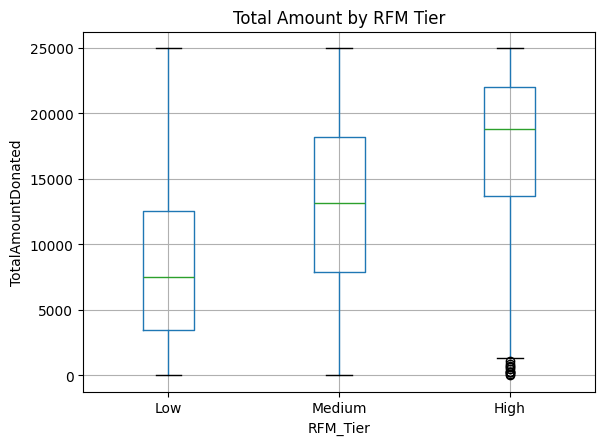

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df.boxplot(column="TotalAmountDonated", by="RFM_Tier")
plt.title("Total Amount by RFM Tier")
plt.suptitle("")
plt.ylabel("TotalAmountDonated")
plt.show()

In [27]:
df.groupby("RFM_Tier").agg({
    "DonorID": "count",
    "TotalGifts": "mean",
    "TotalAmountDonated": "mean",
    "RecencyDays": "mean"
}).round(2)

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/3041463105.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("RFM_Tier").agg({


,DonorID,TotalGifts,TotalAmountDonated,RecencyDays
RFM_Tier,,,,
Low,2118,10.82,8510.88,720.30
Medium,1476,16.24,13048.53,518.85
High,1406,20.92,17400.29,340.98


In [28]:
summary = df.groupby("RFM_Tier").agg({
    "DonorID": "count",
    "TotalGifts": "mean",
    "TotalAmountDonated": "mean",
    "RecencyDays": "mean"
}).round(2)

summary = summary.rename(columns={"DonorID": "DonorCount"})

summary

/var/folders/6v/5x3lt45j1g38g59v9b1y6lhm0000gn/T/ipykernel_9835/1148308090.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("RFM_Tier").agg({


,DonorCount,TotalGifts,TotalAmountDonated,RecencyDays
RFM_Tier,,,,
Low,2118,10.82,8510.88,720.30
Medium,1476,16.24,13048.53,518.85
High,1406,20.92,17400.29,340.98


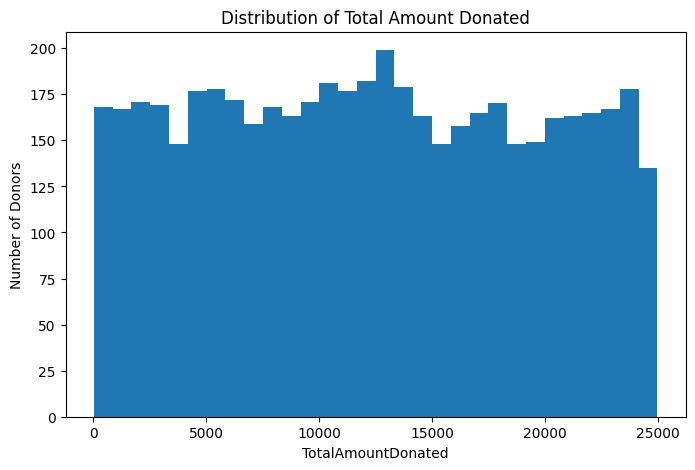

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["TotalAmountDonated"], bins=30)
plt.title("Distribution of Total Amount Donated")
plt.xlabel("TotalAmountDonated")
plt.ylabel("Number of Donors")
plt.show()

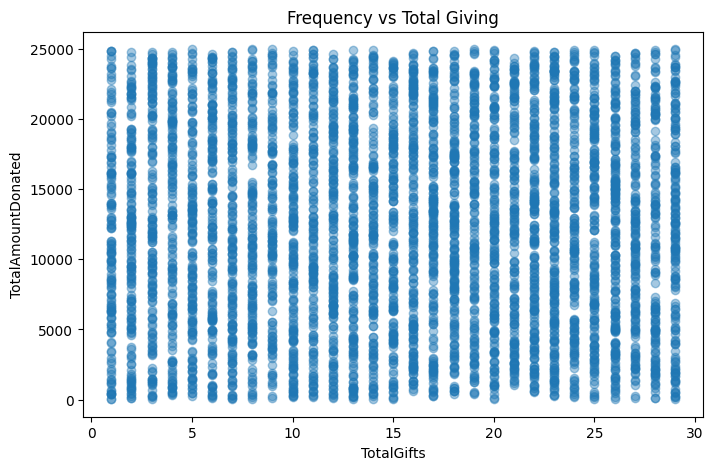

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df["TotalGifts"], df["TotalAmountDonated"], alpha=0.4)
plt.title("Frequency vs Total Giving")
plt.xlabel("TotalGifts")
plt.ylabel("TotalAmountDonated")
plt.show()

### Insight: Frequency vs Lifetime Giving

**What we see:**  
There is a clear upward relationship between gift frequency and cumulative donation value. Donors with higher total gift counts are capable of reaching significantly greater lifetime contribution levels.

**Why it matters:**  
Repeat giving behavior is a strong predictor of lifetime value. Retention-focused stewardship strategies (such as recurring gift programs, targeted re-engagement campaigns, and personalized follow-ups) may increase mid-tier donor conversion into high-value segments.

In [31]:
pareto = df.sort_values("TotalAmountDonated", ascending=False)

pareto["CumulativeRevenue"] = pareto["TotalAmountDonated"].cumsum()
pareto["CumulativeRevenue_%"] = (
    pareto["CumulativeRevenue"] / pareto["TotalAmountDonated"].sum()
) * 100

pareto["DonorRank_%"] = (
    range(1, len(pareto)+1)
)

pareto["DonorRank_%"] = pareto["DonorRank_%"] / len(pareto) * 100

pareto.head()

,DonorID,FirstName,LastName,Email,Phone,City,State,ZipCode,LastDonationDate,TotalGifts,...,EngagementTier,RecencyDays,R_Score,F_Score,M_Score,RFM_Score,RFM_Tier,CumulativeRevenue,CumulativeRevenue_%,DonorRank_%
4857,D04858,Cheryl,Estes,kerriparks@hotmail.com,+1-141-214-5566x44577,West Jeffery,FL,2263,2023-07-31,5,...,Low,598,3,1,5,9,Medium,24991.84,0.040472,0.02
3835,D03836,Louis,Cochran,jacob64@reynolds.com,634-315-2082x580,Lewisside,TN,90639,2024-04-24,9,...,Medium,330,4,2,5,11,High,49979.48,0.080938,0.04
31,D00032,Jessica,Gilbert,omartinez@gmail.com,001-557-999-0072x566,East Wesleyberg,MS,27906,2025-01-16,19,...,Medium,63,5,4,5,14,High,74966.01,0.121401,0.06
666,D00667,Krystal,Garcia,jordansusan@yahoo.com,489-441-3999,North Nancymouth,NC,31598,2024-01-28,8,...,High,417,4,2,5,11,High,99946.21,0.161855,0.08
1363,D01364,Justin,Davis,cherylgomez@gmail.com,6287345129,Lamborough,MA,14199,2024-10-27,29,...,Low,144,5,5,5,15,High,124918.85,0.202296,0.10


In [32]:
top_20_cutoff = pareto[pareto["DonorRank_%"] <= 20]

top_20_revenue_share = top_20_cutoff["TotalAmountDonated"].sum() / df["TotalAmountDonated"].sum() * 100

top_20_revenue_share

np.float64(36.22157678762962)

### Insight: Revenue Concentration (Pareto Analysis)

**What we see:**  
The top 20% of donors contribute approximately 36% of total revenue. Revenue is moderately concentrated but not fully dominated by a small ultra-major donor base.

**Why it matters:**  
While high-value donors are important, this organization does not rely exclusively on a small elite segment. Both top-tier stewardship and broad-based retention strategies are necessary to sustain revenue growth.

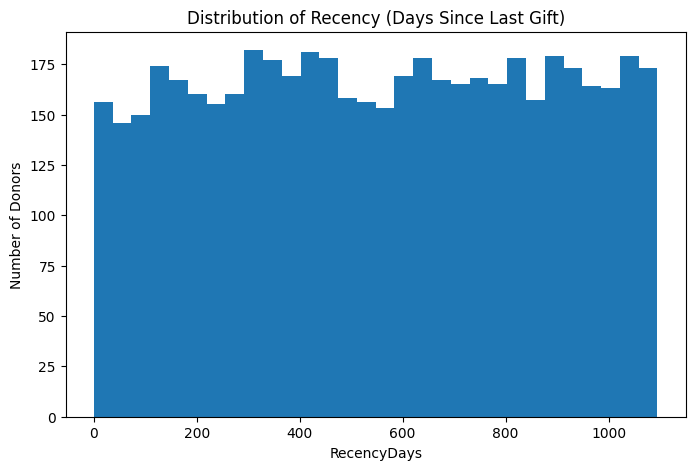

In [33]:
plt.figure(figsize=(8,5))
plt.hist(df["RecencyDays"], bins=30)
plt.title("Distribution of Recency (Days Since Last Gift)")
plt.xlabel("RecencyDays")
plt.ylabel("Number of Donors")
plt.show()

### Insight: Recency Distribution

**What we see:**  
Recency values are broadly distributed, with many donors having long gaps since their last contribution. This indicates a substantial portion of the donor file may be at risk of lapse.

**Why it matters:**  
Recency is a key retention indicator. Donors with extended time since last gift represent re-engagement opportunities. Targeted renewal campaigns, reminder outreach, and segmented communications could improve retention rates and stabilize recurring revenue.

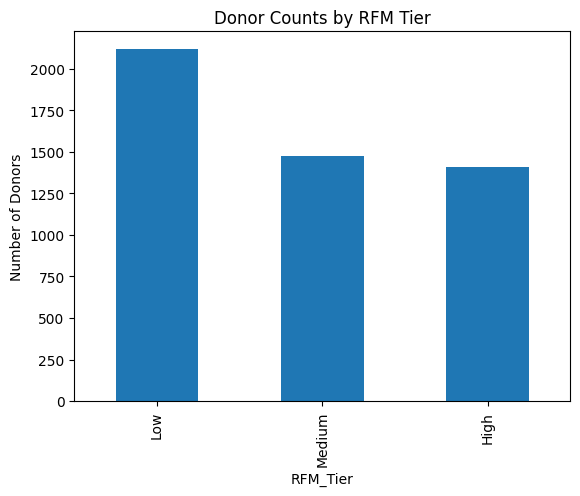

In [35]:
df["RFM_Tier"].value_counts().plot(kind="bar")
plt.title("Donor Counts by RFM Tier")
plt.xlabel("RFM_Tier")
plt.ylabel("Number of Donors")
plt.show()

### Insight: RFM Segmentation Distribution

**What we see:**  
The donor file is distributed across multiple RFM tiers, indicating a mix of high-value, mid-tier, and lower-engagement donors.

**Why it matters:**  
RFM segmentation enables targeted strategy:
- High RFM donors → Major gift cultivation & stewardship
- Mid-tier donors → Upgrade & recurring gift campaigns
- Low RFM donors → Re-engagement & retention focus

This segmentation supports data-driven portfolio assignment and campaign design.

## Dormant Donor Risk (365+ Days Inactive)
To evaluate donor retention risk, donors were classified as dormant if they had not made a donation in the past 365 days.

Dormant donors represent potential revenue loss and highlight opportunities for targeted re-engagement campaigns.

### Insight

A significant portion of the donor base has been inactive for over one year.

This suggests potential revenue recovery opportunities through targeted donor re-engagement strategies such as personalized outreach, campaign segmentation, and retention programs.

In [42]:
# Identify dormant donors (no donation in past 365 days)

analysis_date = pd.to_datetime(df['LastDonationDate']).max()

df['days_since_last_gift'] = (
    analysis_date - pd.to_datetime(df['LastDonationDate'])
).dt.days

dormant_donors = df[df['days_since_last_gift'] > 365]

dormant_rate = len(dormant_donors) / df['DonorID'].nunique()

print("Dormant Donor Rate:", round(dormant_rate * 100, 2), "%")

Dormant Donor Rate: 67.32 %


In [41]:
df.columns

Index(['DonorID', 'FirstName', 'LastName', 'Email', 'Phone', 'City', 'State',
       'ZipCode', 'LastDonationDate', 'TotalGifts', 'TotalAmountDonated',
       'EventParticipation', 'EngagementScore', 'EngagementTier',
       'RecencyDays', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
       'RFM_Tier'],
      dtype='object')

## Revenue Concentration (Pareto Analysis)
To evaluate revenue concentration, donors were ranked by their total lifetime giving.

This analysis tests whether a small proportion of donors generate the majority of revenue, a common pattern known as the Pareto Principle (80/20 rule).

In [43]:
# Pareto revenue concentration analysis

donor_revenue = df.groupby("DonorID")["TotalAmountDonated"].sum().sort_values(ascending=False)

cumulative_revenue = donor_revenue.cumsum()
total_revenue = donor_revenue.sum()

cumulative_percent = cumulative_revenue / total_revenue

pareto_df = cumulative_percent.reset_index()

pareto_df.columns = ["DonorID", "CumulativeRevenuePercent"]

pareto_df.head()

,DonorID,CumulativeRevenuePercent
0,D04858,0.000405
1,D03836,0.000809
2,D00032,0.001214
3,D00667,0.001619
4,D01364,0.002023


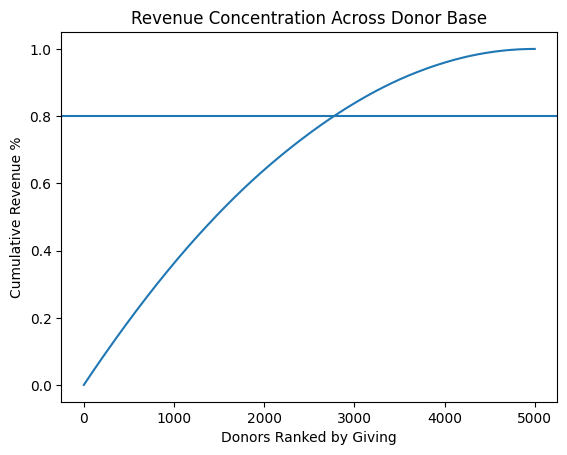

In [44]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(pareto_df["CumulativeRevenuePercent"])

plt.axhline(y=0.8)

plt.title("Revenue Concentration Across Donor Base")

plt.xlabel("Donors Ranked by Giving")

plt.ylabel("Cumulative Revenue %")

plt.show()

### Insight

Revenue is highly concentrated among a relatively small segment of donors.

This pattern supports the importance of targeted stewardship and relationship management strategies for high-value donors, while also highlighting opportunities to grow mid-tier donor engagement.